# Phase 3 - EDA and KPI computation

Computes every KPI in **PROJECT_BRIEF.md section 3**, using those exact names,
from `data/clean/`. Each KPI is reported overall and by `season_year` so the
decline is measurable season over season.

Two definitional notes that affect how the numbers should be read:

* **Revenue** = `price_inr` on **Completed** bookings only. Cancelled and
  no-show bookings are treated as zero revenue (no deposit model is specified
  in the brief). The 23 quarantined prices (C6) are excluded from revenue
  numerators but still counted in every volume KPI.
* **2023-24 is a half season** (Jan-May 2024). Rates are comparable across all
  three; *volumes* are not. Every trend claim is made on the two full seasons.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")   # capture figures in the notebook

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
CLEAN = os.path.join(ROOT, "data", "clean")
con = sqlite3.connect(os.path.join(CLEAN, "dive_ops_clean.db"))

bk = pd.read_sql("SELECT * FROM bookings", con, parse_dates=["booking_date", "dive_date"])
cu = pd.read_sql("SELECT * FROM customers", con, parse_dates=["signup_date"])
iq = pd.read_sql("SELECT * FROM inquiries", con, parse_dates=["inquiry_date"])
tp = pd.read_sql("SELECT * FROM trips", con)
wx = pd.read_sql("SELECT * FROM weather", con, parse_dates=["weather_date"])

SEASONS = ["2023-24 (half)", "2024-25", "2025-26"]
FULL = ["2024-25", "2025-26"]          # the two comparable seasons

# one enriched fact table used throughout
f = (bk.merge(tp, on="trip_id", how="left")
       .merge(cu[["customer_id", "nationality", "cert_level", "acquisition_channel"]],
              on="customer_id", how="left")
       .merge(wx.rename(columns={"weather_date": "dive_date"}), on="dive_date", how="left"))
f["completed"] = f["status"] == "Completed"
f["cancelled"] = f["status"] == "Cancelled"
f["noshow"] = f["status"] == "No-show"

print("fact table: %d bookings, %s -> %s" % (len(f), f.dive_date.min().date(),
                                             f.dive_date.max().date()))
kpi = []      # tidy KPI store: (kpi, scope, value, numerator, denominator)


def rec(name, scope, value, num=np.nan, den=np.nan, unit="ratio"):
    kpi.append({"kpi": name, "scope": scope, "value": value,
                "numerator": num, "denominator": den, "unit": unit})

fact table: 7171 bookings, 2024-01-01 -> 2026-05-31


## `capacity_utilization`

> Completed seats booked / total boat slots available, per trip/season.

Denominator is `SUM(boat_capacity)` over trips that actually sailed; numerator
counts **Completed** bookings only, so cancellations and no-shows correctly
read as unsold capacity.

In [2]:
trip_season = f.groupby("trip_id").agg(season_year=("season_year", "first"),
                                       season=("season", "first"),
                                       dive_ym=("dive_ym", "first"))
cap = tp.set_index("trip_id")["boat_capacity"].to_frame().join(trip_season)
seats = f[f.completed].groupby("trip_id").size().rename("completed_seats")
cap = cap.join(seats).fillna({"completed_seats": 0})

overall = cap["completed_seats"].sum() / cap["boat_capacity"].sum()
rec("capacity_utilization", "overall", overall, cap["completed_seats"].sum(),
    cap["boat_capacity"].sum())
print("capacity_utilization overall: %.1f%%" % (100 * overall))

util_season = (cap.groupby("season_year")
                  .apply(lambda g: g["completed_seats"].sum() / g["boat_capacity"].sum(),
                         include_groups=False)
                  .reindex(SEASONS))
for s, v in util_season.items():
    rec("capacity_utilization", s, v)
print("\nby season_year:\n", (100 * util_season).round(1).to_string())

util_trading = (cap.groupby("season")
                   .apply(lambda g: g["completed_seats"].sum() / g["boat_capacity"].sum(),
                          include_groups=False))
for s, v in util_trading.items():
    rec("capacity_utilization", "trading:" + s, v)
print("\nby trading season:\n", (100 * util_trading).round(1).to_string())

# month x season_year matrix -> the dashboard heatmap
heat = (cap.groupby(["season_year", "dive_ym"])
           .apply(lambda g: g["completed_seats"].sum() / g["boat_capacity"].sum(),
                  include_groups=False)
           .rename("capacity_utilization").reset_index())
heat["month"] = pd.to_datetime(heat["dive_ym"]).dt.month
heat_pivot = heat.pivot_table(index="season_year", columns="month",
                              values="capacity_utilization").reindex(SEASONS)
print("\nutilization heatmap (season_year x calendar month):")
print((100 * heat_pivot).round(1).to_string())

capacity_utilization overall: 59.5%

by season_year:
 season_year
2023-24 (half)    68.3
2024-25           58.0
2025-26           54.5

by trading season:
 season
Monsoon-Closed     9.5
Peak              63.7
Shoulder          56.2

utilization heatmap (season_year x calendar month):
month             1     2     3     4     5     6     9     10    11    12
season_year                                                               
2023-24 (half)  70.7  69.2  68.3  67.0  63.3   NaN   NaN   NaN   NaN   NaN
2024-25         61.9  63.6  61.7  55.1  53.1  10.3   9.8  55.3  59.0  59.0
2025-26         61.2  58.3  61.6  49.5  50.6   7.2  13.0  55.1  52.2  61.1


## `booking_conversion_rate`

> Confirmed bookings / inquiries.

`status` has no "Confirmed" value, so this is read as: **an inquiry that
produced a booking converted**. Numerator = inquiries with a non-null
`converted_booking_id`. Flagged in the generator docstring as A6 - if
"confirmed" was meant to exclude bookings that later cancelled, swap the
numerator for the `_net` variant computed alongside.

In [3]:
conv = iq["converted"].mean()
rec("booking_conversion_rate", "overall", conv, iq["converted"].sum(), len(iq))
print("booking_conversion_rate overall: %.1f%%  (%d of %d inquiries)"
      % (100 * conv, iq["converted"].sum(), len(iq)))

conv_season = iq.groupby("season_year")["converted"].agg(["mean", "sum", "size"]).reindex(SEASONS)
for s, r in conv_season.iterrows():
    rec("booking_conversion_rate", s, r["mean"], r["sum"], r["size"])
print("\nby season_year:")
print(conv_season.assign(pct=(100 * conv_season["mean"]).round(1)).to_string())

# alternative numerator: inquiries that produced a booking that actually completed
completed_ids = set(f.loc[f.completed, "booking_id"])
iq["converted_net"] = iq["converted_booking_id"].isin(completed_ids)
print("\nbooking_conversion_rate (net of later cancellation): %.1f%%"
      % (100 * iq["converted_net"].mean()))
rec("booking_conversion_rate_net", "overall", iq["converted_net"].mean())

conv_channel = iq.groupby("channel")["converted"].agg(["mean", "size"]).sort_values("mean")
print("\nby channel:")
print(conv_channel.assign(pct=(100 * conv_channel["mean"]).round(1)).to_string())

booking_conversion_rate overall: 51.3%  (5562 of 10845 inquiries)

by season_year:
                    mean   sum  size   pct
season_year                               
2023-24 (half)  0.611735  1470  2403  61.2
2024-25         0.530913  2267  4270  53.1
2025-26         0.437440  1825  4172  43.7

booking_conversion_rate (net of later cancellation): 39.3%



by channel:
                   mean  size   pct
channel                            
OTA            0.479005  2453  47.9
Instagram      0.503341  1347  50.3
Walk-in        0.512060  2529  51.2
Website        0.527996  2036  52.8
Referral       0.537050  1417  53.7
Hotel Partner  0.543744  1063  54.4


## `cancellation_rate` (and split by `cancellation_reason`) and `no_show_rate`

In [4]:
canc = f["cancelled"].mean()
nosh = f["noshow"].mean()
rec("cancellation_rate", "overall", canc, f["cancelled"].sum(), len(f))
rec("no_show_rate", "overall", nosh, f["noshow"].sum(), len(f))
print("cancellation_rate overall: %.1f%%   no_show_rate overall: %.1f%%"
      % (100 * canc, 100 * nosh))

rates = f.groupby("season_year")[["cancelled", "noshow"]].mean().reindex(SEASONS)
rates["bookings"] = f.groupby("season_year").size().reindex(SEASONS)
for s, r in rates.iterrows():
    rec("cancellation_rate", s, r["cancelled"])
    rec("no_show_rate", s, r["noshow"])
print("\nby season_year:")
print((rates.assign(cancellation_rate=(100 * rates["cancelled"]).round(1),
                    no_show_rate=(100 * rates["noshow"]).round(1))
       [["bookings", "cancellation_rate", "no_show_rate"]]).to_string())

# split by reason - share of ALL bookings, so components sum to cancellation_rate
reason = (f[f.cancelled].groupby(["season_year", "cancellation_reason"]).size()
          .unstack(fill_value=0).reindex(SEASONS))
reason_rate = reason.div(f.groupby("season_year").size().reindex(SEASONS), axis=0)
print("\ncancellation_rate split by cancellation_reason (%% of all bookings):")
print((100 * reason_rate).round(2).to_string())
print("\ncancellation counts by reason:")
print(reason.to_string())
for col in reason_rate.columns:
    rec("cancellation_rate", "reason:" + col,
        f.loc[f.cancelled, "cancellation_reason"].eq(col).sum() / len(f))

overall_reason = f.loc[f.cancelled, "cancellation_reason"].value_counts()
print("\noverall reason mix (%% of cancellations):")
print((100 * overall_reason / overall_reason.sum()).round(1).to_string())

cancellation_rate overall: 18.6%   no_show_rate overall: 4.8%

by season_year:
                bookings  cancellation_rate  no_show_rate
season_year                                              
2023-24 (half)      1891                9.7           3.5
2024-25             2884               18.5           5.0
2025-26             2396               25.7           5.6

cancellation_rate split by cancellation_reason (%% of all bookings):
cancellation_reason  Customer  Medical  Unknown  Weather
season_year                                             
2023-24 (half)           3.23     1.80     0.74     3.91
2024-25                  6.52     1.91     2.12     7.98
2025-26                  8.06     2.84     5.05     9.77

cancellation counts by reason:
cancellation_reason  Customer  Medical  Unknown  Weather
season_year                                             
2023-24 (half)             61       34       14       74
2024-25                   188       55       61      230
2025-26         


overall reason mix (%% of cancellations):
cancellation_reason
Weather     40.4
Customer    33.2
Unknown     14.7
Medical     11.8


## Cancellation drivers: weather and channel

The brief plants a weather/cancellation correlation. The question that matters
commercially is how much of the cancellation book weather actually explains.

In [5]:
by_wx = f.groupby("sea_condition").agg(
    bookings=("booking_id", "size"),
    cancellation_rate=("cancelled", "mean"),
    weather_reason=("cancellation_reason", lambda s: (s == "Weather").sum()),
    unknown_reason=("cancellation_reason", lambda s: (s == "Unknown").sum()),
).reindex(["Calm", "Moderate", "Rough", "Closed"])
by_wx["cancellation_rate"] = (100 * by_wx["cancellation_rate"]).round(1)
print("by sea_condition:\n", by_wx.to_string())

print("\nshare of all bookings falling on Rough/Closed days: %.1f%%"
      % (100 * f["sea_condition"].isin(["Rough", "Closed"]).mean()))
print("share of all CANCELLATIONS on Rough/Closed days    : %.1f%%"
      % (100 * f.loc[f.cancelled, "sea_condition"].isin(["Rough", "Closed"]).mean()))
print("share of cancellations on Calm/Moderate days       : %.1f%%"
      % (100 * f.loc[f.cancelled, "sea_condition"].isin(["Calm", "Moderate"]).mean()))

by_ch = f.groupby("acquisition_channel").agg(
    bookings=("booking_id", "size"),
    cancellation_rate=("cancelled", "mean"),
    no_show_rate=("noshow", "mean"),
    avg_price=("price_inr", "mean"),
    revenue=("revenue_inr", "sum"),
).sort_values("cancellation_rate", ascending=False)
by_ch["lost_seats"] = (f.groupby("acquisition_channel")["cancelled"].sum()
                       + f.groupby("acquisition_channel")["noshow"].sum())
print("\nby acquisition_channel:")
print(by_ch.assign(cancellation_rate=(100 * by_ch["cancellation_rate"]).round(1),
                   no_show_rate=(100 * by_ch["no_show_rate"]).round(1),
                   avg_price=by_ch["avg_price"].round(0),
                   revenue=by_ch["revenue"].round(0)).to_string())

ota_share = (f.groupby("season_year")["acquisition_channel"]
             .apply(lambda s: (s == "OTA").mean()).reindex(SEASONS))
print("\nOTA share of bookings by season: \n", (100 * ota_share).round(1).to_string())

by sea_condition:
                bookings  cancellation_rate  weather_reason  unknown_reason
sea_condition                                                             
Calm               3705               10.0              31              62
Moderate           2464               16.8              82              62
Rough               719               45.2             240              43
Closed              283               78.8             185              29

share of all bookings falling on Rough/Closed days: 14.0%
share of all CANCELLATIONS on Rough/Closed days    : 41.1%
share of cancellations on Calm/Moderate days       : 58.9%

by acquisition_channel:
                     bookings  cancellation_rate  no_show_rate  avg_price     revenue  lost_seats
acquisition_channel                                                                              
OTA                      1377               27.8           7.5     8167.0   7235300.0         486
Hotel Partner             661      


OTA share of bookings by season: 
 season_year
2023-24 (half)     8.5
2024-25           17.8
2025-26           29.4


## `repeat_customer_rate` and `course_to_fundive_conversion`

In [6]:
comp = f[f.completed]
per_cust = comp.groupby("customer_id").size()
repeat_n = int((per_cust > 1).sum())
repeat_rate = repeat_n / len(cu)
rec("repeat_customer_rate", "overall", repeat_rate, repeat_n, len(cu))
print("repeat_customer_rate: %.1f%%  (%d of %d customers have >1 completed booking)"
      % (100 * repeat_rate, repeat_n, len(cu)))
print("completed bookings per customer:\n",
      per_cust.value_counts().sort_index().to_string())

# course -> fun dive, requiring the fun dive to come AFTER the first course
comp_sorted = comp.sort_values("dive_date")
first_course = (comp_sorted[comp_sorted.dive_type == "Course"]
                .groupby("customer_id")["dive_date"].min())
fun = comp_sorted[comp_sorted.dive_type == "Fun Dive"][["customer_id", "dive_date"]]
fun_after = (fun.merge(first_course.rename("first_course"), on="customer_id")
                .query("dive_date > first_course")["customer_id"].nunique())
c2f = fun_after / len(first_course)
rec("course_to_fundive_conversion", "overall", c2f, fun_after, len(first_course))
print("\ncourse_to_fundive_conversion: %.1f%%  (%d of %d course customers returned "
      "for a fun dive)" % (100 * c2f, fun_after, len(first_course)))

# by the season the course was taken in
fc = first_course.rename("first_course").to_frame()
fc["season_year"] = fc["first_course"].map(
    lambda d: "2023-24 (half)" if d <= pd.Timestamp("2024-05-31")
    else ("2024-25" if d <= pd.Timestamp("2025-05-31") else "2025-26"))
returned = set(fun.merge(first_course.rename("first_course"), on="customer_id")
                  .query("dive_date > first_course")["customer_id"])
fc["returned"] = fc.index.isin(returned)
c2f_season = fc.groupby("season_year")["returned"].agg(["mean", "sum", "size"]).reindex(SEASONS)
for s, r in c2f_season.iterrows():
    rec("course_to_fundive_conversion", s, r["mean"], r["sum"], r["size"])
print("\nby season the course was taken:")
print(c2f_season.assign(pct=(100 * c2f_season["mean"]).round(1)).to_string())

repeat_customer_rate: 16.0%  (877 of 5495 customers have >1 completed booking)
completed bookings per customer:
 1    3489
2     700
3     126
4      35
5      10
6       6



course_to_fundive_conversion: 21.5%  (185 of 860 course customers returned for a fun dive)



by season the course was taken:
                    mean  sum  size   pct
season_year                              
2023-24 (half)  0.394649  118   299  39.5
2024-25         0.161017   57   354  16.1
2025-26         0.048309   10   207   4.8


### Is the course_to_fundive decline real, or just censoring?

The by-cohort numbers above are **right-censored**: a customer who took a
course in April 2026 has had a few weeks to come back, while the 2023-24
cohort has had two years. Some decline is guaranteed by the shape of the
window alone, so the headline number cannot be trusted as-is.

Fair test: a fixed **90-day return window**, restricted to course customers
whose first course was at least 90 days before the data ends (2026-05-31).
69% of everyone who ever returned did so within 90 days, so the window
captures most of the real signal.

In [7]:
DATA_END = pd.Timestamp("2026-05-31")
fc2 = first_course.rename("first_course").to_frame()
fc2["season_year"] = fc2["first_course"].map(
    lambda d: "2023-24 (half)" if d <= pd.Timestamp("2024-05-31")
    else ("2024-25" if d <= pd.Timestamp("2025-05-31") else "2025-26"))
fc2["days_observable"] = (DATA_END - fc2["first_course"]).dt.days

gaps = fun.merge(first_course.rename("fc"), on="customer_id")
gaps["gap"] = (gaps["dive_date"] - gaps["fc"]).dt.days
fc2 = fc2.join(gaps[gaps.gap > 0].groupby("customer_id")["gap"].min().rename("days_to_return"))

print("of everyone who returned, %.0f%% did so within 90 days (median %.0f days)"
      % (100 * (fc2["days_to_return"] <= 90).sum() / fc2["days_to_return"].notna().sum(),
         fc2["days_to_return"].median()))
print("\n2025-26 course customers with <90 days of observation: %d of %d (%.0f%%)"
      % ((fc2.loc[fc2.season_year == "2025-26", "days_observable"] < 90).sum(),
         (fc2.season_year == "2025-26").sum(),
         100 * (fc2.loc[fc2.season_year == "2025-26", "days_observable"] < 90).mean()))

fair = fc2[fc2["days_observable"] >= 90].copy()
fair["returned_90d"] = fair["days_to_return"].le(90)
fair_rate = fair.groupby("season_year")["returned_90d"].agg(["size", "sum", "mean"]).reindex(SEASONS)
print("\n90-day conversion on a like-for-like observation window:")
print(fair_rate.assign(pct=(100 * fair_rate["mean"]).round(1)).to_string())
for s, r in fair_rate.iterrows():
    rec("course_to_fundive_conversion_90d", s, r["mean"], r["sum"], r["size"])
print("\nVERDICT: unrestricted %.1f%% -> %.1f%% -> %.1f%% vs censoring-corrected "
      "%.1f%% -> %.1f%% -> %.1f%%.\nThe decline survives the correction, so it is a "
      "real retention collapse, not a measurement window artefact."
      % tuple(list(100 * c2f_season["mean"].values) + list(100 * fair_rate["mean"].values)))

of everyone who returned, 69% did so within 90 days (median 49 days)



2025-26 course customers with <90 days of observation: 73 of 207 (35%)

90-day conversion on a like-for-like observation window:
                size  sum      mean   pct
season_year                              
2023-24 (half)   299   83  0.277592  27.8
2024-25          354   36  0.101695  10.2
2025-26          134    5  0.037313   3.7

VERDICT: unrestricted 39.5% -> 16.1% -> 4.8% vs censoring-corrected 27.8% -> 10.2% -> 3.7%.
The decline survives the correction, so it is a real retention collapse, not a measurement window artefact.


In [8]:
repeat_season = (comp.groupby(["season_year", "customer_id"]).size().rename("n")
                 .reset_index().groupby("season_year")["n"]
                 .apply(lambda s: (s > 1).mean()).reindex(SEASONS))
for s, v in repeat_season.items():
    rec("repeat_customer_rate", "within:" + s, v)
print("\nrepeat rate WITHIN each season (customers diving >1x in that season):")
print((100 * repeat_season).round(1).to_string())


repeat rate WITHIN each season (customers diving >1x in that season):
season_year
2023-24 (half)    27.4
2024-25           13.5
2025-26            8.0


## Revenue KPIs

`revenue_per_customer` and `customer_ltv` are near-identical as defined in the
brief (total revenue / distinct customers vs mean revenue per customer). To
keep them distinct and both meaningful:

* `revenue_per_customer` - total revenue / **all** customers on file, including
  those who never completed a dive. This is the acquisition-efficiency view.
* `customer_ltv` - mean lifetime revenue across customers who completed **at
  least one** dive. This is the value-of-a-diver view.

Flagged: if the brief intends them identical, use `customer_ltv`.

In [9]:
total_rev = f["revenue_inr"].sum()
completed_dives = int(comp["num_dives"].sum())

rpc = total_rev / cu["customer_id"].nunique()
rpd = total_rev / completed_dives

# min_count=1 so a customer whose only completed booking had a quarantined price
# (C6) yields NaN, not 0. Their lifetime value is UNKNOWN, not zero, and mean()
# skips them. Without this the LTV mean is dragged down by fake zeros and stops
# matching sql/03_retention_repeat_course.sql, where SUM() returns NULL and AVG()
# ignores it.
cust_rev = comp.groupby("customer_id")["revenue_inr"].sum(min_count=1)
print("customers with completed dives but unusable revenue (excluded from LTV): %d"
      % int(cust_rev.isna().sum()))
ltv = cust_rev.mean()

rec("revenue_per_customer", "overall", rpc, total_rev, cu["customer_id"].nunique(), "INR")
rec("revenue_per_dive", "overall", rpd, total_rev, completed_dives, "INR")
rec("customer_ltv", "overall", ltv, total_rev, int(cust_rev.notna().sum()), "INR")
rec("total_revenue", "overall", total_rev, unit="INR")

print("total revenue (Completed only) : Rs %,.0f".replace(",", "") % total_rev)
print("total completed dives          : %d" % completed_dives)
print("revenue_per_customer           : Rs %.0f  (over %d customers)"
      % (rpc, cu["customer_id"].nunique()))
print("revenue_per_dive               : Rs %.0f" % rpd)
print("customer_ltv                   : Rs %.0f  (over %d diving customers)"
      % (ltv, len(cust_rev)))

rev_season = f.groupby("season_year").agg(
    revenue=("revenue_inr", "sum"),
    completed=("completed", "sum"),
    dives=("num_dives", lambda s: np.nan)).reindex(SEASONS)
rev_season["dives"] = comp.groupby("season_year")["num_dives"].sum().reindex(SEASONS)
rev_season["customers"] = comp.groupby("season_year")["customer_id"].nunique().reindex(SEASONS)
rev_season["revenue_per_dive"] = rev_season["revenue"] / rev_season["dives"]
rev_season["revenue_per_customer"] = rev_season["revenue"] / rev_season["customers"]
for s, r in rev_season.iterrows():
    rec("revenue_per_dive", s, r["revenue_per_dive"], unit="INR")
    rec("revenue_per_customer", s, r["revenue_per_customer"], unit="INR")
    rec("total_revenue", s, r["revenue"], unit="INR")
print("\nby season_year:")
print(rev_season.round(0).to_string())

full_delta = (rev_season.loc["2025-26", "revenue"] - rev_season.loc["2024-25", "revenue"])
print("\nfull-season revenue change 2024-25 -> 2025-26: Rs %.0f (%.1f%%)"
      % (full_delta, 100 * full_delta / rev_season.loc["2024-25", "revenue"]))

customers with completed dives but unusable revenue (excluded from LTV): 13
total revenue (Completed only) : Rs 54950350
total completed dives          : 12349
revenue_per_customer           : Rs 10000  (over 5495 customers)
revenue_per_dive               : Rs 4450
customer_ltv                   : Rs 12624  (over 4366 diving customers)



by season_year:
                   revenue  completed  dives  customers  revenue_per_dive  revenue_per_customer
season_year                                                                                    
2023-24 (half)  18135350.0       1641   3873       1183            4683.0               15330.0
2024-25         22250950.0       2206   4986       1918            4463.0               11601.0
2025-26         14564050.0       1646   3490       1519            4173.0                9588.0

full-season revenue change 2024-25 -> 2025-26: Rs -7686900 (-34.5%)


In [10]:
by_product = f.groupby("dive_type").agg(
    bookings=("booking_id", "size"),
    completed=("completed", "sum"),
    revenue=("revenue_inr", "sum"),
    avg_price=("price_inr", "mean"),
    cancellation_rate=("cancelled", "mean"))
by_product["revenue_share"] = by_product["revenue"] / by_product["revenue"].sum()
print("revenue by product:")
print(by_product.assign(cancellation_rate=(100 * by_product["cancellation_rate"]).round(1),
                        revenue_share=(100 * by_product["revenue_share"]).round(1),
                        avg_price=by_product["avg_price"].round(0)).to_string())

course_share = (f.groupby("season_year")["dive_type"]
                .apply(lambda s: (s == "Course").mean()).reindex(SEASONS))
print("\nCourse share of bookings by season:\n", (100 * course_share).round(1).to_string())

unknown_rev = f.loc[f.acquisition_channel == "Unknown", "revenue_inr"].sum()
print("\nrevenue with NO channel attribution: Rs %.0f (%.1f%% of total)"
      % (unknown_rev, 100 * unknown_rev / total_rev))

revenue by product:
                bookings  completed     revenue  avg_price  cancellation_rate  revenue_share
dive_type                                                                                   
Course              1219        913  23253650.0    25352.0               20.3           42.3
Discovery Dive      2158       1636   9291150.0     5622.0               19.0           16.9
Fun Dive            3794       2944  22405550.0     7568.0               17.8           40.8

Course share of bookings by season:
 season_year
2023-24 (half)    20.2
2024-25           17.8
2025-26           13.5

revenue with NO channel attribution: Rs 5096000 (9.3% of total)


## `seasonality_index`

> Monthly bookings indexed to the monthly mean (mean = 100).

Calendar months are unevenly covered by 2.5 seasons: Jan-May occur three times
in the window, Oct-Dec only twice. Averaging raw totals would understate
Oct-Dec. We therefore index the **mean bookings per occurrence** of each
calendar month.

In [11]:
month_tot = f.groupby("dive_month").size()
occurrences = f.groupby("dive_month")["dive_ym"].nunique()
month_mean = (month_tot / occurrences).reindex(range(1, 13), fill_value=0.0)
seasonality_index = 100 * month_mean / month_mean.mean()

si = pd.DataFrame({"bookings_total": month_tot.reindex(range(1, 13), fill_value=0),
                   "months_observed": occurrences.reindex(range(1, 13), fill_value=0),
                   "mean_per_month": month_mean.round(1),
                   "seasonality_index": seasonality_index.round(1)})
si.index.name = "calendar_month"
print(si.to_string())
for m, v in seasonality_index.items():
    rec("seasonality_index", "month:%02d" % m, v, unit="index")
print("\npeak month: %d (index %.0f) | trough among trading months: %d (index %.0f)"
      % (seasonality_index.idxmax(), seasonality_index.max(),
         seasonality_index[seasonality_index > 0].idxmin(),
         seasonality_index[seasonality_index > 0].min()))

                bookings_total  months_observed  mean_per_month  seasonality_index
calendar_month                                                                    
1                         1309                3           436.3              192.1
2                         1166                3           388.7              171.1
3                         1114                3           371.3              163.5
4                          826                3           275.3              121.2
5                          742                3           247.3              108.9
6                           41                2            20.5                9.0
7                            0                0             0.0                0.0
8                            0                0             0.0                0.0
9                           41                2            20.5                9.0
10                         529                2           264.5              116.4
11  

## Quantifying the leak

Two gaps worth pricing, both used by the Phase 5 memo:

1. **Empty seats.** Slots that sailed unsold, valued at the mean revenue of a
   completed booking.
2. **The utilization gap.** What closing 2025-26 utilization to the 75% target
   in section 9 would be worth.

In [12]:
mean_seat_rev = comp["revenue_inr"].mean()
print("mean revenue per completed booking (seat): Rs %.0f" % mean_seat_rev)

leak = pd.DataFrame(index=SEASONS)
leak["slots"] = cap.groupby("season_year")["boat_capacity"].sum().reindex(SEASONS)
leak["completed_seats"] = cap.groupby("season_year")["completed_seats"].sum().reindex(SEASONS)
leak["empty_seats"] = leak["slots"] - leak["completed_seats"]
leak["cancelled"] = f.groupby("season_year")["cancelled"].sum().reindex(SEASONS)
leak["noshow"] = f.groupby("season_year")["noshow"].sum().reindex(SEASONS)
leak["never_sold"] = leak["empty_seats"] - leak["cancelled"] - leak["noshow"]
leak["value_cancelled_noshow"] = (leak["cancelled"] + leak["noshow"]) * mean_seat_rev
leak["value_empty_seats"] = leak["empty_seats"] * mean_seat_rev
print("\n", leak.round(0).to_string())

cur = "2025-26"
gap_seats = leak.loc[cur, "slots"] * 0.75 - leak.loc[cur, "completed_seats"]
print("\n2025-26: utilization %.1f%%; reaching the 75%% target in section 9 needs "
      "%.0f more completed seats" % (100 * util_season[cur], gap_seats))
print("value of that gap at Rs %.0f/seat: Rs %.0f" % (mean_seat_rev,
                                                      gap_seats * mean_seat_rev))
rec("empty_seat_value", cur, leak.loc[cur, "value_empty_seats"], unit="INR")
rec("utilization_gap_to_75_seats", cur, gap_seats, unit="seats")
rec("utilization_gap_to_75_value", cur, gap_seats * mean_seat_rev, unit="INR")
rec("mean_revenue_per_seat", "overall", mean_seat_rev, unit="INR")

# recoverable subset: cancellations NOT attributable to weather
non_weather = f[f.cancelled & (f.cancellation_reason != "Weather")]
print("\ncancellations not attributed to Weather: %d (%.1f%% of all cancellations), "
      "worth Rs %.0f" % (len(non_weather), 100 * len(non_weather) / f["cancelled"].sum(),
                         len(non_weather) * mean_seat_rev))
rec("non_weather_cancellations", "overall", len(non_weather), unit="bookings")
rec("non_weather_cancellation_value", "overall", len(non_weather) * mean_seat_rev, unit="INR")

mean revenue per completed booking (seat): Rs 10035

                 slots  completed_seats  empty_seats  cancelled  noshow  never_sold  value_cancelled_noshow  value_empty_seats
2023-24 (half)   2402           1641.0        761.0        183      67       511.0               2508690.0          7636453.0
2024-25          3806           2206.0       1600.0        534     144       922.0               6803568.0         16055617.0
2025-26          3022           1646.0       1376.0        616     134       626.0               7526071.0         13807831.0

2025-26: utilization 54.5%; reaching the 75% target in section 9 needs 620 more completed seats
value of that gap at Rs 10035/seat: Rs 6226569

cancellations not attributed to Weather: 795 (59.6% of all cancellations), worth Rs 7977635


## Charts

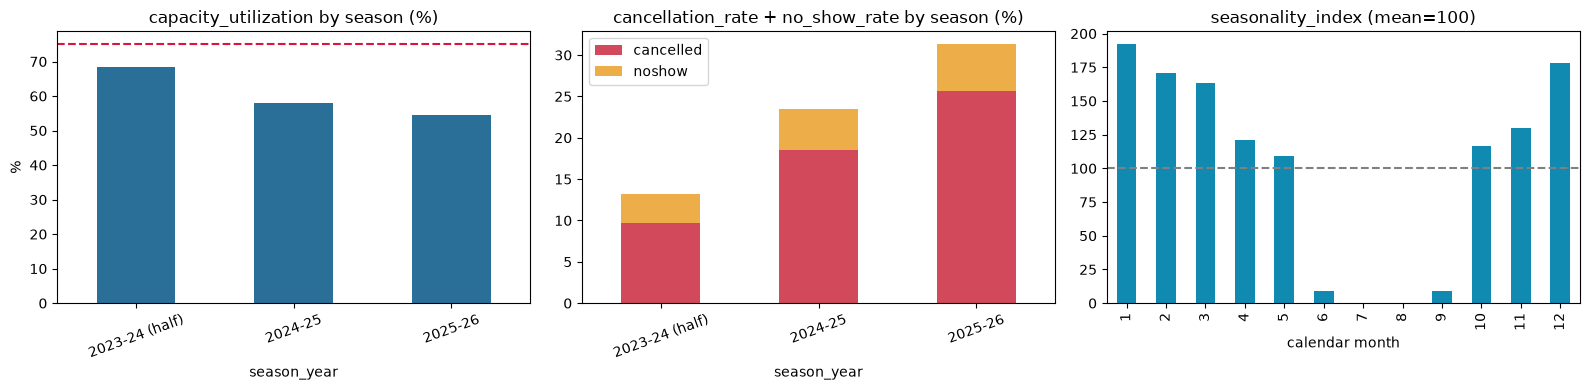

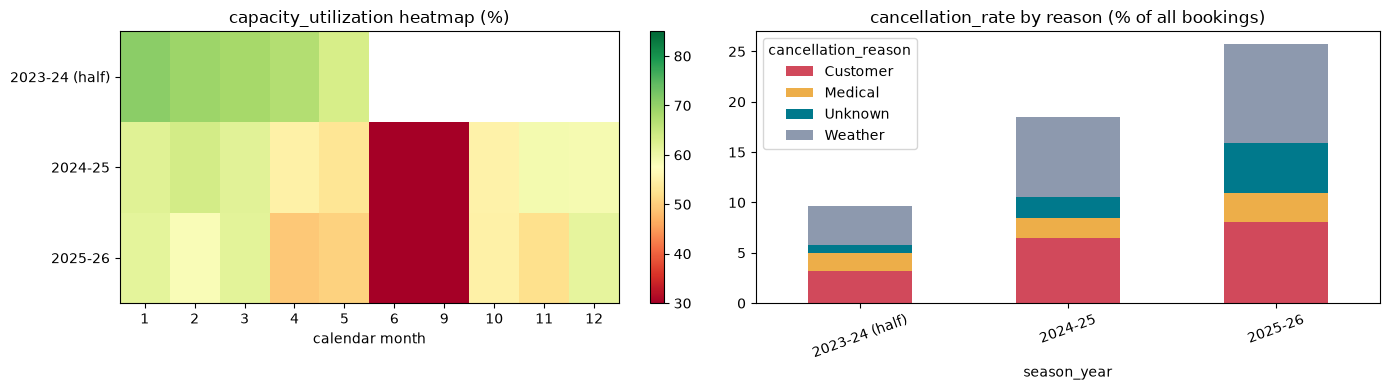

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
(100 * util_season).plot(kind="bar", ax=ax[0], color="#2a6f97")
ax[0].axhline(75, ls="--", c="crimson"); ax[0].set_title("capacity_utilization by season (%)")
ax[0].set_ylabel("%"); ax[0].tick_params(axis="x", rotation=20)

rr = rates[["cancelled", "noshow"]] * 100
rr.plot(kind="bar", stacked=True, ax=ax[1], color=["#d1495b", "#edae49"])
ax[1].set_title("cancellation_rate + no_show_rate by season (%)")
ax[1].tick_params(axis="x", rotation=20)

seasonality_index.plot(kind="bar", ax=ax[2], color="#118ab2")
ax[2].axhline(100, ls="--", c="grey"); ax[2].set_title("seasonality_index (mean=100)")
ax[2].set_xlabel("calendar month")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
im = ax[0].imshow(heat_pivot.values * 100, aspect="auto", cmap="RdYlGn", vmin=30, vmax=85)
ax[0].set_yticks(range(len(heat_pivot))); ax[0].set_yticklabels(heat_pivot.index)
ax[0].set_xticks(range(len(heat_pivot.columns))); ax[0].set_xticklabels(heat_pivot.columns)
ax[0].set_title("capacity_utilization heatmap (%)"); ax[0].set_xlabel("calendar month")
plt.colorbar(im, ax=ax[0])

(100 * reason_rate).plot(kind="bar", stacked=True, ax=ax[1],
                         color=["#d1495b", "#edae49", "#00798c", "#8d99ae"])
ax[1].set_title("cancellation_rate by reason (% of all bookings)")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## KPI summary table

Written to `data/clean/kpi_summary.csv`; Phase 4 turns it into the dashboard
card source and `docs/FINDINGS.md` quotes it.

In [14]:
ks = pd.DataFrame(kpi)
ks.to_csv(os.path.join(CLEAN, "kpi_summary.csv"), index=False)

hdr = ks[ks.scope.isin(["overall"] + SEASONS)].copy()
pivot = hdr.pivot_table(index="kpi", columns="scope", values="value", aggfunc="first")
pivot = pivot.reindex(columns=["overall"] + SEASONS)
print("ALL SECTION-3 KPIs")
print("=" * 100)
for k in ["capacity_utilization", "booking_conversion_rate", "cancellation_rate",
          "no_show_rate", "repeat_customer_rate", "course_to_fundive_conversion",
          "revenue_per_customer", "revenue_per_dive", "customer_ltv"]:
    if k in pivot.index:
        row = pivot.loc[k]
        unit = ks.loc[ks.kpi == k, "unit"].iloc[0]
        fmt = (lambda v: "  n/a" if pd.isna(v) else
               ("%9.1f%%" % (100 * v) if unit == "ratio" else "Rs %9.0f" % v))
        print("%-30s %s" % (k, "  ".join(fmt(row.get(c)) for c in pivot.columns)))
print("%-30s %s" % ("", "  ".join("%10s" % c for c in pivot.columns)))
print("\nseasonality_index by month:")
print("  " + "  ".join("%02d:%.0f" % (m, v) for m, v in seasonality_index.items()))
con.close()

ALL SECTION-3 KPIs
capacity_utilization                59.5%       68.3%       58.0%       54.5%
booking_conversion_rate             51.3%       61.2%       53.1%       43.7%
cancellation_rate                   18.6%        9.7%       18.5%       25.7%
no_show_rate                         4.8%        3.5%        5.0%        5.6%
repeat_customer_rate                16.0%    n/a    n/a    n/a
course_to_fundive_conversion        21.5%       39.5%       16.1%        4.8%
revenue_per_customer           Rs     10000  Rs     15330  Rs     11601  Rs      9588
revenue_per_dive               Rs      4450  Rs      4683  Rs      4463  Rs      4173
customer_ltv                   Rs     12624    n/a    n/a    n/a
                                  overall  2023-24 (half)     2024-25     2025-26

seasonality_index by month:
  01:192  02:171  03:163  04:121  05:109  06:9  07:0  08:0  09:9  10:116  11:130  12:179
